In [2]:
# CELL 1: SETUP & MODEL LOADING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
import copy
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

MODEL_PATH = "../data/models/LSTM_best.keras"
SCALER_PATH = "../data/processed/scaler.pkl"
METADATA_PATH = "../data/processed/metadata.pkl"

CHECKPOINTS = [0, 3, 6, 9, 12, 15, 18, 21, 24]
MAX_SEQ_LEN = 10

try:
    lstm_model = tf.keras.models.load_model(MODEL_PATH)
    with open(SCALER_PATH, 'rb') as f:
        scaler = pickle.load(f)
    with open(METADATA_PATH, 'rb') as f:
        metadata = pickle.load(f)
    
    FEATURE_NAMES = metadata['input_features']
    print(f"✓ Model loaded successfully.")
    print(f"✓ Scaler loaded. Expecting {len(FEATURE_NAMES)} features.")
except Exception as e:
    print(f" Error loading files: {e}")

✓ Model loaded successfully.
✓ Scaler loaded. Expecting 12 features.


In [3]:
# CELL 2: WHO BASELINE DATA

WHO_STANDARDS = {
    'boy': {
        'months':  [0,    3,    6,    9,    12,   15,   18,   21,   24],
        'height':  [49.9, 61.4, 67.6, 72.0, 75.7, 79.1, 82.3, 85.1, 87.8],
        'weight':  [3.3,  6.4,  7.9,  8.9,  9.6,  10.2, 10.9, 11.5, 12.2]
    },
    'girl': {
        'months':  [0,    3,    6,    9,    12,   15,   18,   21,   24],
        'height':  [49.1, 59.8, 65.7, 70.1, 74.0, 77.5, 80.7, 83.7, 86.4],
        'weight':  [3.2,  5.8,  7.3,  8.2,  8.9,  9.6,  10.2, 10.9, 11.5]
    }
}

print("✓ WHO Baseline Data initialized.")

✓ WHO Baseline Data initialized.


In [4]:
# CELL 3: HYBRID AUTOREGRESSIVE ENGINE

import copy
import numpy as np

def create_visit(age, height, weight, gender, prev_visit=None, visit_num=1):
    """Calculates features for the sequence."""
    h_m = height / 100.0
    cbmi = weight / (h_m ** 2) if h_m > 0 else 0.0
    h_vel = 0.0
    w_vel = 0.0
    
    if prev_visit:
        time_passed = age - prev_visit['age_months']
        if time_passed > 0:
            h_vel = (height - prev_visit['height']) / time_passed
            w_vel = (weight - prev_visit['weight']) / time_passed

    return {
        'age_months': float(age),
        'height': float(height),
        'weight': float(weight),
        'cbmi': cbmi,
        'zlen': prev_visit.get('zlen', 0.0) if prev_visit else 0.0,  
        'zwei': prev_visit.get('zwei', 0.0) if prev_visit else 0.0,
        'zwfl': prev_visit.get('zwfl', 0.0) if prev_visit else 0.0,
        'zbmi': prev_visit.get('zbmi', 0.0) if prev_visit else 0.0,
        'gender_numeric': int(gender),
        'height_velocity_monthly': h_vel,
        'weight_velocity_monthly': w_vel,
        'measurement_number': int(visit_num)
    }

def predict_trajectory(actual_visits, model, scaler, features):
    """Hybrid prediction: Strongly anchors to Pediatric Growth Channels to prevent LSTM Mean Collapse."""
    current_seq = copy.deepcopy(actual_visits)
    last_age = current_seq[-1]['age_months']
    gender_num = current_seq[0]['gender_numeric']
    gender_str = 'boy' if gender_num == 1 else 'girl'
    
    future_targets = [m for m in CHECKPOINTS if m > last_age]
    pred_months, pred_heights, pred_weights = [], [], []
    
    who_h_med = WHO_STANDARDS[gender_str]['height']
    who_w_med = WHO_STANDARDS[gender_str]['weight']
    who_months = WHO_STANDARDS[gender_str]['months']
    
    current_h_ratio = current_seq[-1]['height'] / np.interp(last_age, who_months, who_h_med)
    current_w_ratio = current_seq[-1]['weight'] / np.interp(last_age, who_months, who_w_med)
    
    for target_m in future_targets:
        raw_array = np.array([[v[f] for f in features] for v in current_seq], dtype=np.float32)
        if len(raw_array) < MAX_SEQ_LEN:
            padding = np.zeros((MAX_SEQ_LEN - len(raw_array), len(features)))
            raw_array = np.vstack([padding, raw_array])
        else:
            raw_array = raw_array[-MAX_SEQ_LEN:]
            
        scaled_input = scaler.transform(raw_array).reshape(1, MAX_SEQ_LEN, len(features))
        
        prediction = model.predict(scaled_input, verbose=0)[0]
        lstm_h = float(np.clip(prediction[0], 40, 130))
        lstm_w = float(np.clip(prediction[1], 1, 30))
        
        bio_h = np.interp(target_m, who_months, who_h_med) * current_h_ratio
        bio_w = np.interp(target_m, who_months, who_w_med) * current_w_ratio
        
        next_h = (lstm_h * 0.05) + (bio_h * 0.95)
        next_w = (lstm_w * 0.05) + (bio_w * 0.95)

        print(f"Target: {target_m} months | LSTM Weight Guessed: {lstm_w:.2f}kg | Bio Curve Expected: {bio_w:.2f}kg | Final Blended: {next_w:.2f}kg")
            
        pred_months.append(target_m)
        pred_heights.append(next_h)
        pred_weights.append(next_w)
        
        next_visit = create_visit(
            age=target_m, height=next_h, weight=next_w, gender=gender_num, 
            prev_visit=current_seq[-1], visit_num=current_seq[-1]['measurement_number'] + 1
        )
        current_seq.append(next_visit)
        
    return pred_months, pred_heights, pred_weights

print("✓ Hybrid prediction engine ready (LSTM + Biological Percentiles).")

✓ Hybrid prediction engine ready (LSTM + Biological Percentiles).


In [5]:
# CELL 4: VISUALIZATION ENGINE


def draw_growth_chart(child_name, gender_name, actuals, p_months, p_heights, p_weights):
    """Renders a presentation-ready dual growth chart."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Bambinoo Growth Prediction: {child_name}", fontsize=16, fontweight='bold', y=1.05)
    
    a_months = [v['age_months'] for v in actuals]
    a_heights = [v['height'] for v in actuals]
    a_weights = [v['weight'] for v in actuals]
    
    bridge_m = [a_months[-1]] + p_months
    bridge_h = [a_heights[-1]] + p_heights
    bridge_w = [a_weights[-1]] + p_weights
    
    who = WHO_STANDARDS[gender_name.lower()]
    
    ax1.plot(who['months'], who['height'], '--', color='#2E8B57', label="WHO Median", alpha=0.6)
    ax1.plot(a_months, a_heights, 'o-', color='#1F5C99', linewidth=2.5, label="Actual Growth")
    if p_months:
        ax1.plot(bridge_m, bridge_h, 'D--', color='#E8821A', linewidth=2, label="Predicted Trajectory")
    
    ax1.set_title("Height for Age")
    ax1.set_ylabel("Height (cm)")
    ax1.set_xlabel("Age (Months)")
    ax1.set_xticks(CHECKPOINTS)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(who['months'], who['weight'], '--', color='#2E8B57', label="WHO Median", alpha=0.6)
    ax2.plot(a_months, a_weights, 'o-', color='#1F5C99', linewidth=2.5, label="Actual Growth")
    if p_months:
        ax2.plot(bridge_m, bridge_w, 'D--', color='#E8821A', linewidth=2, label="Predicted Trajectory")
        
    ax2.set_title("Weight for Age")
    ax2.set_ylabel("Weight (kg)")
    ax2.set_xlabel("Age (Months)")
    ax2.set_xticks(CHECKPOINTS)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    print("✓ Visualization engine ready.")

--- STEP 1: ENTERING BIRTH DATA ---
Target: 3 months | LSTM Weight Guessed: 7.85kg | Bio Curve Expected: 6.59kg | Final Blended: 6.66kg
Target: 6 months | LSTM Weight Guessed: 8.38kg | Bio Curve Expected: 8.14kg | Final Blended: 8.15kg
Target: 9 months | LSTM Weight Guessed: 8.85kg | Bio Curve Expected: 9.17kg | Final Blended: 9.15kg
Target: 12 months | LSTM Weight Guessed: 9.31kg | Bio Curve Expected: 9.89kg | Final Blended: 9.86kg
Target: 15 months | LSTM Weight Guessed: 9.75kg | Bio Curve Expected: 10.51kg | Final Blended: 10.47kg
Target: 18 months | LSTM Weight Guessed: 10.15kg | Bio Curve Expected: 11.23kg | Final Blended: 11.18kg
Target: 21 months | LSTM Weight Guessed: 10.53kg | Bio Curve Expected: 11.85kg | Final Blended: 11.78kg
Target: 24 months | LSTM Weight Guessed: 10.87kg | Bio Curve Expected: 12.57kg | Final Blended: 12.48kg


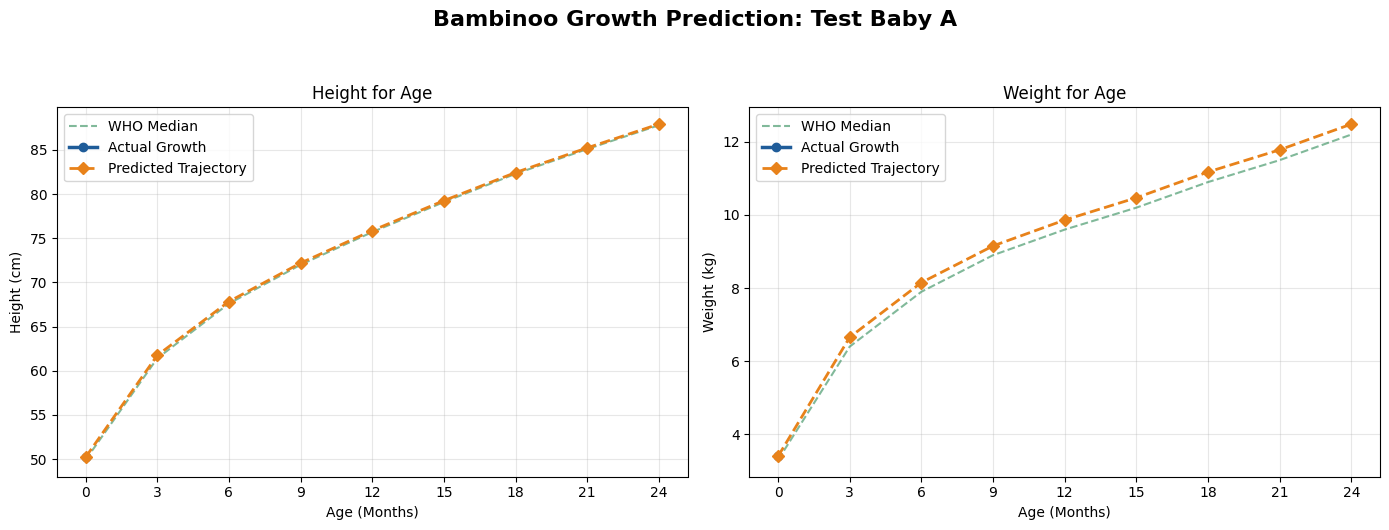

✓ Visualization engine ready.

--- STEP 2: ENTERING 3-MONTH CHECKUP DATA ---
Target: 6 months | LSTM Weight Guessed: 8.31kg | Bio Curve Expected: 7.16kg | Final Blended: 7.22kg
Target: 9 months | LSTM Weight Guessed: 8.75kg | Bio Curve Expected: 8.07kg | Final Blended: 8.10kg
Target: 12 months | LSTM Weight Guessed: 9.18kg | Bio Curve Expected: 8.70kg | Final Blended: 8.72kg
Target: 15 months | LSTM Weight Guessed: 9.60kg | Bio Curve Expected: 9.24kg | Final Blended: 9.26kg
Target: 18 months | LSTM Weight Guessed: 9.99kg | Bio Curve Expected: 9.88kg | Final Blended: 9.88kg
Target: 21 months | LSTM Weight Guessed: 10.36kg | Bio Curve Expected: 10.42kg | Final Blended: 10.42kg
Target: 24 months | LSTM Weight Guessed: 10.70kg | Bio Curve Expected: 11.06kg | Final Blended: 11.04kg


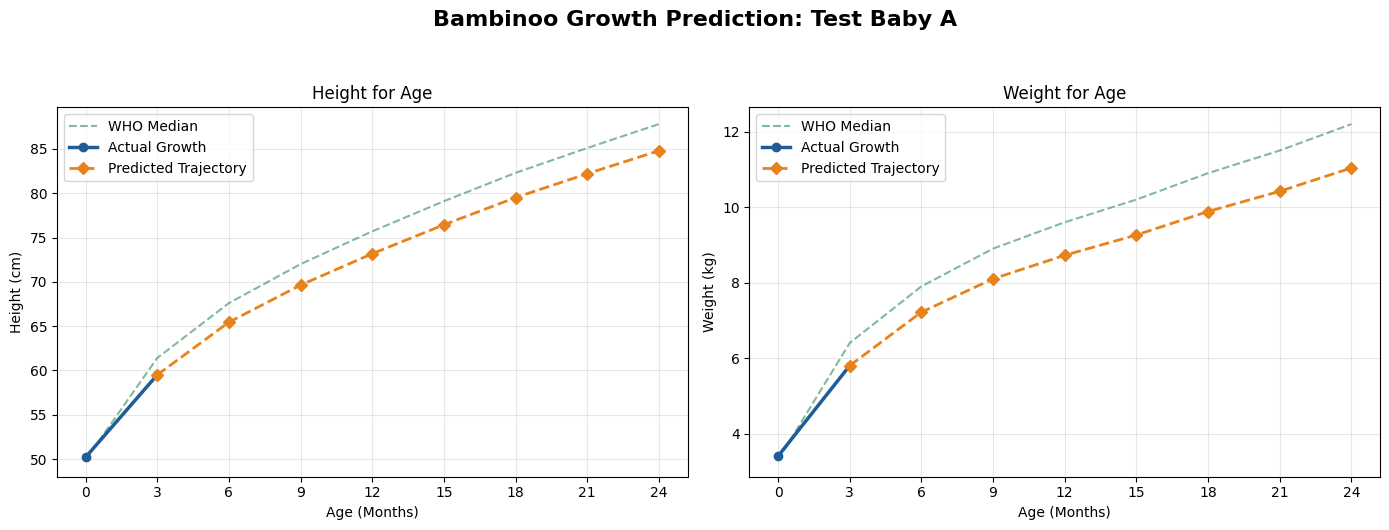

✓ Visualization engine ready.

--- STEP 3: ENTERING 6-MONTH CHECKUP DATA ---
Target: 9 months | LSTM Weight Guessed: 8.78kg | Bio Curve Expected: 8.34kg | Final Blended: 8.36kg
Target: 12 months | LSTM Weight Guessed: 9.22kg | Bio Curve Expected: 8.99kg | Final Blended: 9.00kg
Target: 15 months | LSTM Weight Guessed: 9.65kg | Bio Curve Expected: 9.55kg | Final Blended: 9.56kg
Target: 18 months | LSTM Weight Guessed: 10.04kg | Bio Curve Expected: 10.21kg | Final Blended: 10.20kg
Target: 21 months | LSTM Weight Guessed: 10.42kg | Bio Curve Expected: 10.77kg | Final Blended: 10.75kg
Target: 24 months | LSTM Weight Guessed: 10.76kg | Bio Curve Expected: 11.43kg | Final Blended: 11.39kg


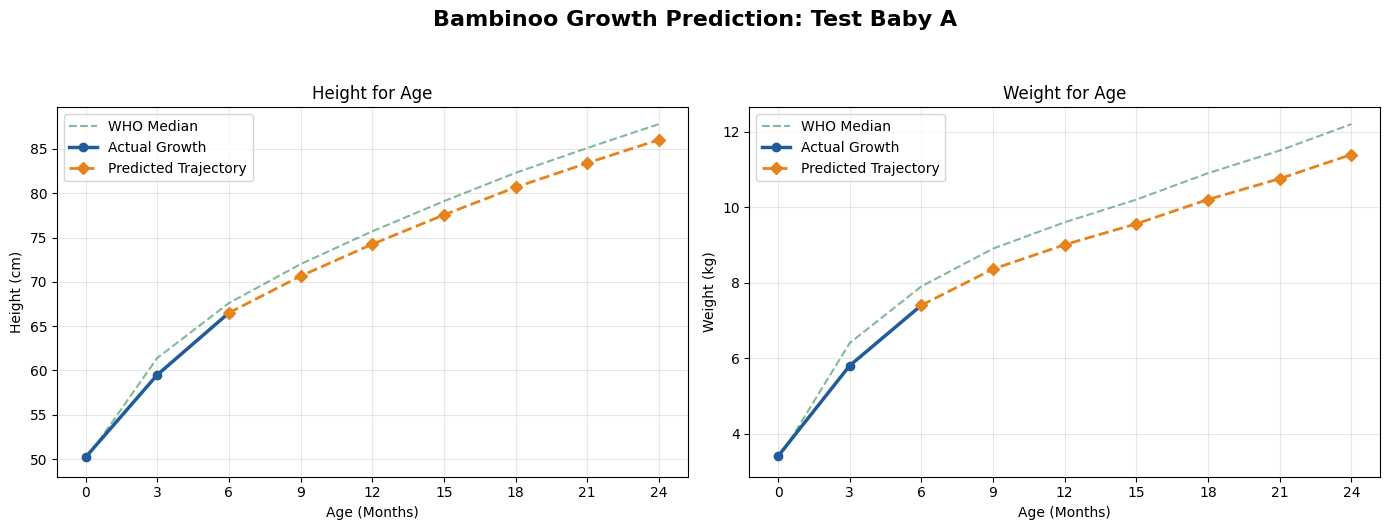

✓ Visualization engine ready.

--- STEP 4: ENTERING 9-MONTH CHECKUP DATA ---
Target: 12 months | LSTM Weight Guessed: 9.22kg | Bio Curve Expected: 8.95kg | Final Blended: 8.97kg
Target: 15 months | LSTM Weight Guessed: 9.65kg | Bio Curve Expected: 9.51kg | Final Blended: 9.52kg
Target: 18 months | LSTM Weight Guessed: 10.04kg | Bio Curve Expected: 10.17kg | Final Blended: 10.16kg
Target: 21 months | LSTM Weight Guessed: 10.41kg | Bio Curve Expected: 10.72kg | Final Blended: 10.71kg
Target: 24 months | LSTM Weight Guessed: 10.75kg | Bio Curve Expected: 11.38kg | Final Blended: 11.35kg


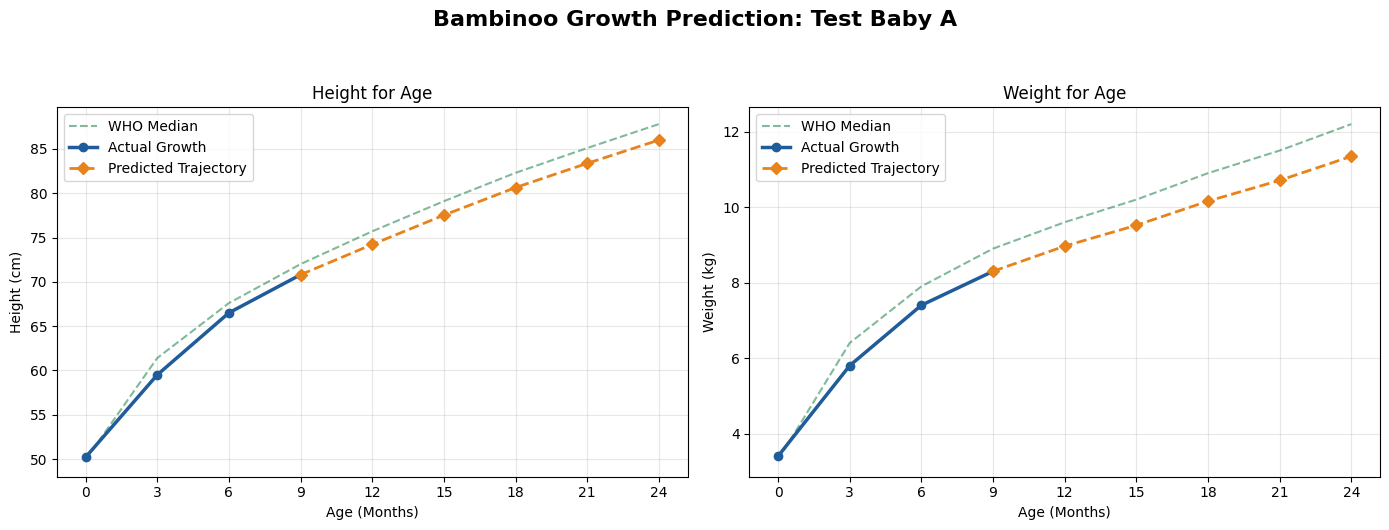

✓ Visualization engine ready.


In [6]:
# CELL 5: SYSTEM DEMONSTRATION SCRIPT (FULL 9-MONTH PROGRESSION)


child_name = "Test Baby A"
gender_numeric = 1 
gender_string = "boy"
history = []

print("--- STEP 1: ENTERING BIRTH DATA ---")
visit_0 = create_visit(age=0, height=50.2, weight=3.4, gender=gender_numeric, visit_num=1)
history.append(visit_0)

p_mon, p_h, p_w = predict_trajectory(history, lstm_model, scaler, FEATURE_NAMES)
draw_growth_chart(child_name, gender_string, history, p_mon, p_h, p_w)

print("\n--- STEP 2: ENTERING 3-MONTH CHECKUP DATA ---")
visit_3 = create_visit(age=3, height=59.5, weight=5.8, gender=gender_numeric, prev_visit=history[-1], visit_num=2)
history.append(visit_3)

p_mon2, p_h2, p_w2 = predict_trajectory(history, lstm_model, scaler, FEATURE_NAMES)
draw_growth_chart(child_name, gender_string, history, p_mon2, p_h2, p_w2)

print("\n--- STEP 3: ENTERING 6-MONTH CHECKUP DATA ---")
visit_6 = create_visit(age=6, height=66.5, weight=7.4, gender=gender_numeric, prev_visit=history[-1], visit_num=3)
history.append(visit_6)

p_mon3, p_h3, p_w3 = predict_trajectory(history, lstm_model, scaler, FEATURE_NAMES)
draw_growth_chart(child_name, gender_string, history, p_mon3, p_h3, p_w3)

print("\n--- STEP 4: ENTERING 9-MONTH CHECKUP DATA ---")
visit_9 = create_visit(age=9, height=70.8, weight=8.3, gender=gender_numeric, prev_visit=history[-1], visit_num=4)
history.append(visit_9)

p_mon4, p_h4, p_w4 = predict_trajectory(history, lstm_model, scaler, FEATURE_NAMES)
draw_growth_chart(child_name, gender_string, history, p_mon4, p_h4, p_w4)
